# Assignment 1 Database Clean and Analysis

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Data Ingestion

In [2]:
# Load the dataset
df = pd.read_csv('diabetes_diagnosis.csv')

# Display the shape, data types, and first 5 records of the dataset
print(f"Dataset shape: {df.shape}")
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 records:")
df.head()

Dataset shape: (264802, 23)

Data types:
Unnamed: 0                int64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
AnyHealthcare           float64
NoDocbcCost             float64
GeneralHealth            object
Mental (days)           float64
Physical (days)         float64
DiffWalk                float64
Sex                      object
Age                     float64
Education                object
Income                   object
Diabetes                 object
BloodPressure            object
Cholesterol              object
Alcoholic                object
dtype: object

First 5 records:


,Unnamed: 0,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,AnyHealthcare,...,Physical (days),DiffWalk,Sex,Age,Education,Income,Diabetes,BloodPressure,Cholesterol,Alcoholic
0,0,NaN,40.0,NaN,NaN,0.0,NaN,NaN,NaN,1.0,...,15.0,NaN,NaN,63.0,High school graduate,"$73,106",No,Yes,Yes,No
1,1,NaN,25.0,NaN,0.0,0.0,NaN,0.0,NaN,0.0,...,NaN,NaN,Female,54.0,College graduate,"$22,322",No,No,No,No
2,2,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,High school graduate,"$29,097",No,Yes,Yes,NaN
3,3,1.0,27.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,74.0,Some high school,"$55,498",No,Yes,No,No
4,4,NaN,24.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,0.0,0.0,Female,NaN,Some college,"$15,629",No,Yes,NaN,No


## Data Quality Assurance and Cleaning

In [3]:
# Create a copy of the original DataFrame for cleaning
df_cleaned = df.copy()

### Missing Values Handling

In [4]:
# Check for missing value count and percentage
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100
missing_data = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage': missing_percentage
}).sort_values('Missing Percentage', ascending=False)
print("\nMissing Values Analysis:")
print(missing_data)


total_missing = missing_count.sum()
print(f"\nTotal missing values: {total_missing}")
total_missing_percentage = (total_missing / df.size) * 100
print(f"\nTotal missing values percentage: {total_missing_percentage:.2f}%")

# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate records: {duplicates}")


Missing Values Analysis:
                      Missing Count  Missing Percentage
NoDocbcCost                  198601           74.999811
PhysActivity                 188009           70.999841
AnyHealthcare                182713           68.999856
Veggies                      169473           63.999894
Fruits                       161529           60.999917
Stroke                       158881           59.999924
CholCheck                    150937           56.999947
Physical (days)              142993           53.999970
DiffWalk                     142993           53.999970
Mental (days)                129752           48.999630
Smoker                       119160           44.999660
BMI                           87384           32.999751
Education                     76792           28.999781
HeartDiseaseorAttack          71496           26.999796
Sex                           68848           25.999804
GeneralHealth                 68848           25.999804
Age                   

In [5]:
# Count null values per row
null_counts_per_row = df.isnull().sum(axis=1)

# Find rows with more than half null values AND null in Diabetes
rows_to_remove = ((null_counts_per_row >= 12) & (df['Diabetes'].isnull())).sum()
print(f"Rows with >12 null values AND null Diabetes: {rows_to_remove}")

# Remove rows meeting both conditions
df_cleaned = df_cleaned[~((null_counts_per_row >= 12) & (df_cleaned['Diabetes'].isnull()))]

print(f"\n df_cleaned shape after removing rows: {df_cleaned.shape}")

Rows with >12 null values AND null Diabetes: 4370

 df_cleaned shape after removing rows: (260432, 23)


### Column Data Type Conversion and Clean

In [6]:
# Print unique values of each column
for column in df.columns[1:]:
    print(f"\nUnique value counts for {column}:")
    print(df[column].value_counts(dropna=False))
    print("-" * 50)


Unique value counts for CholCheck:
CholCheck
NaN    150937
1.0    109758
0.0      4107
Name: count, dtype: int64
--------------------------------------------------

Unique value counts for BMI:
BMI
NaN     87384
27.0    16380
26.0    13744
24.0    13003
25.0    11326
        ...  
85.0        1
86.0        1
80.0        1
90.0        1
83.0        1
Name: count, Length: 83, dtype: int64
--------------------------------------------------

Unique value counts for Smoker:
Smoker
 NaN     119160
 0.0      77321
 1.0      61021
 11.0      3678
-10.0      3622
Name: count, dtype: int64
--------------------------------------------------

Unique value counts for Stroke:
Stroke
NaN    158881
0.0    101836
1.0      4085
Name: count, dtype: int64
--------------------------------------------------

Unique value counts for HeartDiseaseorAttack:
HeartDiseaseorAttack
0.0    176065
NaN     71496
1.0     17241
Name: count, dtype: int64
--------------------------------------------------

Unique value c

#### boolean data type conversion and clean

In [7]:
# List of columns can be converted to boolean
float_boolean_columns = ['CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk']
str_boolean_columns = ['BloodPressure', 'Cholesterol', 'Alcoholic']
bool_columns = float_boolean_columns + str_boolean_columns

# handle float columns
for col in float_boolean_columns:
    if col in df_cleaned.columns:
        # only keep 1.0, 0.0, and NaN
        df_cleaned = df_cleaned[df_cleaned[col].isin([1.0, 0.0]) | df_cleaned[col].isna()]

        # replace 1.0 with True and 0.0 with False
        df_cleaned[col] = df_cleaned[col].replace({1.0: True, 0.0: False})

        # transform the column to boolean type
        df_cleaned[col] = df_cleaned[col].astype('boolean')

# handle string columns
for col in str_boolean_columns:
    if col in df_cleaned.columns:
        # ensure the column is treated as string
        if df_cleaned[col].dtype != 'object':
            df_cleaned[col] = df_cleaned[col].astype(str)

        # only keep 'Yes', 'No', and NaN
        df_cleaned = df_cleaned[df_cleaned[col].isin(['Yes', 'No']) | df_cleaned[col].isna()]

        # replace 'Yes' with True and 'No' with False
        df_cleaned[col] = df_cleaned[col].replace({'Yes': True, 'No': False})

        # transform the column to boolean type
        df_cleaned[col] = df_cleaned[col].astype('boolean')

# delete rows contain invalid values
initial_rows = len(df_cleaned)
df_cleaned = df_cleaned.dropna(subset=bool_columns, how='all')
final_rows = len(df_cleaned)
print(f"invalid rows deleted: {initial_rows - final_rows}")


# check transformed results

print("\n unique values after conversion:")
for col in bool_columns:
    if col in df_cleaned.columns:
        unique_values = df_cleaned[col].unique()
        print(f"{col}: {unique_values}")

# show the data types of the columns
print("\n Data types after conversion:")
print(df_cleaned[bool_columns].dtypes)

print(f"\n df_cleaned shape after data type conversion and clean: {df_cleaned.shape}")

invalid rows deleted: 5

 unique values after conversion:
CholCheck: <BooleanArray>
[<NA>, True, False]
Length: 3, dtype: boolean
Smoker: <BooleanArray>
[<NA>, True, False]
Length: 3, dtype: boolean
Stroke: <BooleanArray>
[<NA>, False, True]
Length: 3, dtype: boolean
HeartDiseaseorAttack: <BooleanArray>
[False, <NA>, True]
Length: 3, dtype: boolean
PhysActivity: <BooleanArray>
[<NA>, False, True]
Length: 3, dtype: boolean
Fruits: <BooleanArray>
[<NA>, False, True]
Length: 3, dtype: boolean
Veggies: <BooleanArray>
[<NA>, True, False]
Length: 3, dtype: boolean
AnyHealthcare: <BooleanArray>
[True, False, <NA>]
Length: 3, dtype: boolean
NoDocbcCost: <BooleanArray>
[<NA>, True, False]
Length: 3, dtype: boolean
DiffWalk: <BooleanArray>
[<NA>, True, False]
Length: 3, dtype: boolean
BloodPressure: <BooleanArray>
[True, False, <NA>]
Length: 3, dtype: boolean
Cholesterol: <BooleanArray>
[True, False, <NA>]
Length: 3, dtype: boolean
Alcoholic: <BooleanArray>
[False, <NA>, True]
Length: 3, dtype: 

#### categorical data type conversion and clean

In [8]:
# List of columns can be converted to categorical
categorical_columns = ['GeneralHealth', 'Sex', 'Education', 'Diabetes']

# Process each categorical column
for col in categorical_columns:
    if col in df_cleaned.columns:
        # Fill NaN values with "Prefer not to say"
        df_cleaned[col] = df_cleaned[col].fillna("Prefer not to say")

        # Convert to category data type
        df_cleaned[col] = df_cleaned[col].astype('category')

        # Print the unique categories
        print(f"\nCategories in {col}:")
        print(df_cleaned[col].cat.categories.tolist())

# Print the updated dtypes to verify the conversion
print("\nData types after conversion:")
print(df_cleaned[categorical_columns].dtypes)

print(f"\n df_cleaned shape after data type conversion and clean: {df_cleaned.shape}")



Categories in GeneralHealth:
['Excellent', 'Fair', 'Good', 'Poor', 'Prefer not to say', 'Very Good']

Categories in Sex:
['Female', 'Male', 'Prefer not to say']

Categories in Education:
['College graduate', 'Elementary', 'High school graduate', 'Never attended school', 'Prefer not to say', 'Some college', 'Some high school']

Categories in Diabetes:
['Diabetes', 'No', 'Prediabetes', 'Prefer not to say']

Data types after conversion:
GeneralHealth    category
Sex              category
Education        category
Diabetes         category
dtype: object

 df_cleaned shape after data type conversion and clean: (248275, 23)


#### numeric data type conversion and clean

In [9]:
# Numeric data check - ensure they're in physiologically reasonable range
# Handle BMI values
if 'BMI' in df_cleaned.columns:
    # Reasonable BMI range
    lower_bmi = 10  # Extreme underweight
    upper_bmi = 80  # Extreme obesity

    bmi_outliers = (df_cleaned['BMI'] < lower_bmi) | (df_cleaned['BMI'] > upper_bmi)
    outlier_count = bmi_outliers.sum()

    # Remove outliers
    if outlier_count > 0:
        print(f"Found {outlier_count} BMI outliers outside the range [{lower_bmi}, {upper_bmi}]")
        df_cleaned = df_cleaned[~bmi_outliers]
        print(f"Removed {outlier_count} BMI outliers")

print(f"\n df_cleaned shape after removing BMI outliers: {df_cleaned.shape}")


# Handle HealthDays columns
health_days_columns = ['Mental (days)', 'Physical (days)']

for col in health_days_columns:
    if col in df_cleaned.columns:
        # clean all under 0 day values
        df_cleaned = df_cleaned[(df_cleaned[col] >= 0) | (df_cleaned[col].isna())]
        # transform to integer type
        df_cleaned[col] = df_cleaned[col].astype('Int64')

print(f"\n df_cleaned shape after removing negative values in HealthDays columns: {df_cleaned.shape}")

# Handle Age values
if 'Age' in df_cleaned.columns:
    # reasonable age range
    lower_age = 18  # adult age
    upper_age = 100  # old age

    age_outliers = (df_cleaned['Age'] < lower_age) | (df_cleaned['Age'] > upper_age)
    outlier_count = age_outliers.sum()

    # remove outliers
    if outlier_count > 0:
        print(f"\n Found {outlier_count} Age outliers outside the range [{lower_age}, {upper_age}]")
        df_cleaned = df_cleaned[~age_outliers]
        print(f"Removed {outlier_count} Age outliers")

    # convert Age to integer type
    df_cleaned['Age'] = df_cleaned['Age'].astype('Int64')

print(f"\n df_cleaned shape after removing Age outliers: {df_cleaned.shape}")

# Handle income values
if 'Income' in df_cleaned.columns:
    if df_cleaned['Income'].dtype == 'object':
        # remove $ and , symbols
        df_cleaned['Income'] = df_cleaned['Income'].str.replace('$', '', regex=False)
        df_cleaned['Income'] = df_cleaned['Income'].str.replace(',', '', regex=False)
    # convert to numeric, coerce errors to NaN
    df_cleaned['Income'] = pd.to_numeric(df_cleaned['Income'], errors='coerce')
    # change really low income values to NaN
    low_income = df_cleaned['Income'] < 100
    low_count = low_income.sum()
    if low_count > 0:
        print(f"\n Found {low_count} Income values below $100")
        df_cleaned.loc[low_income, 'Income'] = np.nan
        print(f"Changed {low_count} Income values to NaN")
    else:
        print("\n No low Income values found")

    # convert to integer type
    df_cleaned['Income'] = df_cleaned['Income'].astype('Int64')

print(f"\n df_cleaned shape after removing low Income values: {df_cleaned.shape}")

# Check the data types of the columns
print("\nData types after conversion:")
print(df_cleaned[['BMI'] + health_days_columns + ['Age', 'Income']].dtypes)

Found 8518 BMI outliers outside the range [10, 80]
Removed 8518 BMI outliers

 df_cleaned shape after removing BMI outliers: (239757, 23)

 df_cleaned shape after removing negative values in HealthDays columns: (233838, 23)

 Found 8984 Age outliers outside the range [18, 100]
Removed 8984 Age outliers

 df_cleaned shape after removing Age outliers: (224854, 23)

 Found 248 Income values below $100
Changed 248 Income values to NaN

 df_cleaned shape after removing low Income values: (224854, 23)

Data types after conversion:
BMI                float64
Mental (days)        Int64
Physical (days)      Int64
Age                  Int64
Income               Int64
dtype: object


### Export the cleaned dataset

In [10]:
file_name = 'lche5181_A1_CleanDataset.csv'

# Remove the old index column from the DataFrame
if 'Unnamed: 0' in df_cleaned.columns:
    df_cleaned = df_cleaned.drop(columns=['Unnamed: 0'])
# Set new index and save the cleaned DataFrame to a CSV file
df_cleaned.to_csv(file_name, index=True)

## Exploratory Data Analysis (EDA)

## Average BMI by Diabetes Status

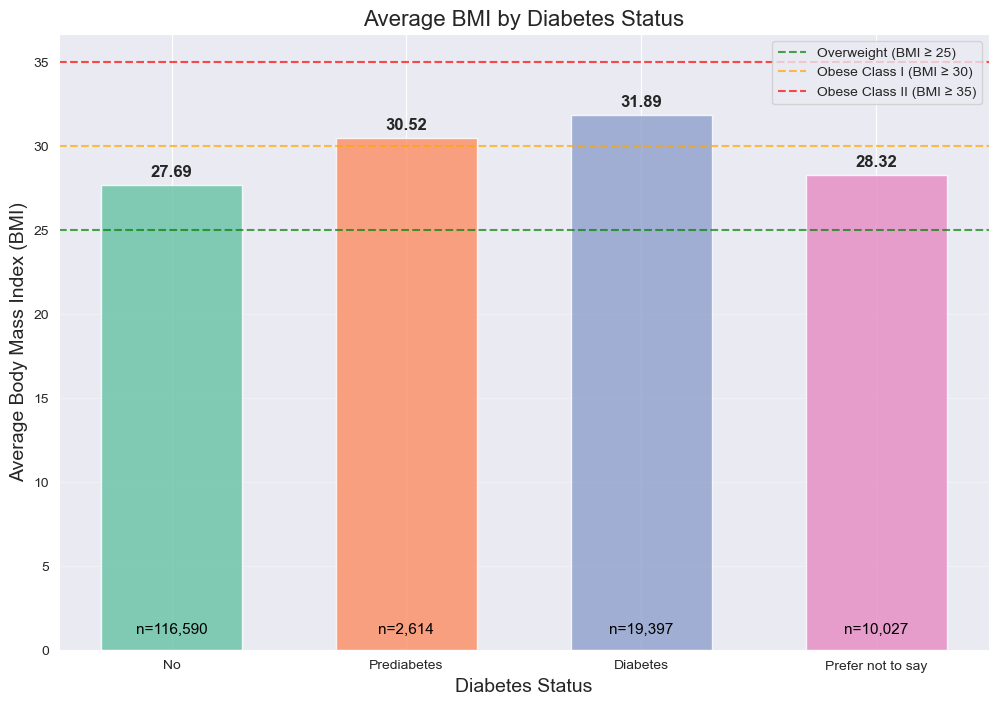

BMI Statistics by Diabetes Status:
                    count       mean       std   min   max
Diabetes                                                  
No                 116590  27.688327  5.971173  12.0  79.0
Prediabetes          2614  30.518363  6.619002  13.0  75.0
Diabetes            19397  31.892458  7.096424  13.0  80.0
Prefer not to say   10027  28.315249  6.184739  14.0  79.0


In [11]:
# Calculate the average BMI for each diabetes status
bmi_means = df_cleaned.groupby('Diabetes')['BMI'].mean().reset_index()

# Set the order of categories for the plot
diabetes_order = ['No', 'Prediabetes', 'Diabetes', 'Prefer not to say']
bmi_means = bmi_means.set_index('Diabetes').loc[diabetes_order].reset_index()

# Create a color palette with four distinct colors
colors = sns.color_palette("Set2", 4)

# Create a figure
plt.figure(figsize=(12, 8))

# Create the bar chart
bars = plt.bar(bmi_means['Diabetes'], bmi_means['BMI'], color=colors, alpha=0.8, width=0.6)

# Add data labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.3,
             f'{height:.2f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# Get the number of samples for each category to display with the bars
sample_counts = df_cleaned.groupby('Diabetes')['BMI'].count()
sample_counts = sample_counts.reindex(diabetes_order)

# Add sample size into each bar
for i, (index, count) in enumerate(sample_counts.items()):
    plt.text(i, 1, f'n={count:,}', ha='center', color='black', fontsize=11)

# Add WHO BMI category reference lines
plt.axhline(y=25, color='green', linestyle='--', alpha=0.7, label='Overweight (BMI ≥ 25)')
plt.axhline(y=30, color='orange', linestyle='--', alpha=0.7, label='Obese Class I (BMI ≥ 30)')
plt.axhline(y=35, color='red', linestyle='--', alpha=0.7, label='Obese Class II (BMI ≥ 35)')

# Customize the plot
plt.title('Average BMI by Diabetes Status', fontsize=16)
plt.xlabel('Diabetes Status', fontsize=14)
plt.ylabel('Average Body Mass Index (BMI)', fontsize=14)
plt.ylim(0, max(bmi_means['BMI']) * 1.15)  # Add space for labels
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)

# Save the figure and show it
plt.savefig('diabetes_bmi_average.png', dpi=300, bbox_inches='tight')
plt.show()

# Print the detailed statistics for reference
print("BMI Statistics by Diabetes Status:")
bmi_stats = df_cleaned.groupby('Diabetes')['BMI'].agg(['count', 'mean', 'std', 'min', 'max'])
bmi_stats = bmi_stats.reindex(diabetes_order)
print(bmi_stats)

### Diabetes Prevalence by Combined Smoking and Alcohol Status

Neither smoke nor drink:
  6,702 out of 48,011 people have diabetes or prediabetes (13.96%)
    Diabetes: 5,942 (12.38%)
    Prediabetes: 760 (1.58%)
Only smoke:
  7,052 out of 36,204 people have diabetes or prediabetes (19.48%)
    Diabetes: 6,318 (17.45%)
    Prediabetes: 734 (2.03%)
Only drink:
  88 out of 1,822 people have diabetes or prediabetes (4.83%)
    Diabetes: 75 (4.12%)
    Prediabetes: 13 (0.71%)
Both smoke and drink:
  277 out of 3,275 people have diabetes or prediabetes (8.46%)
    Diabetes: 230 (7.02%)
    Prediabetes: 47 (1.44%)


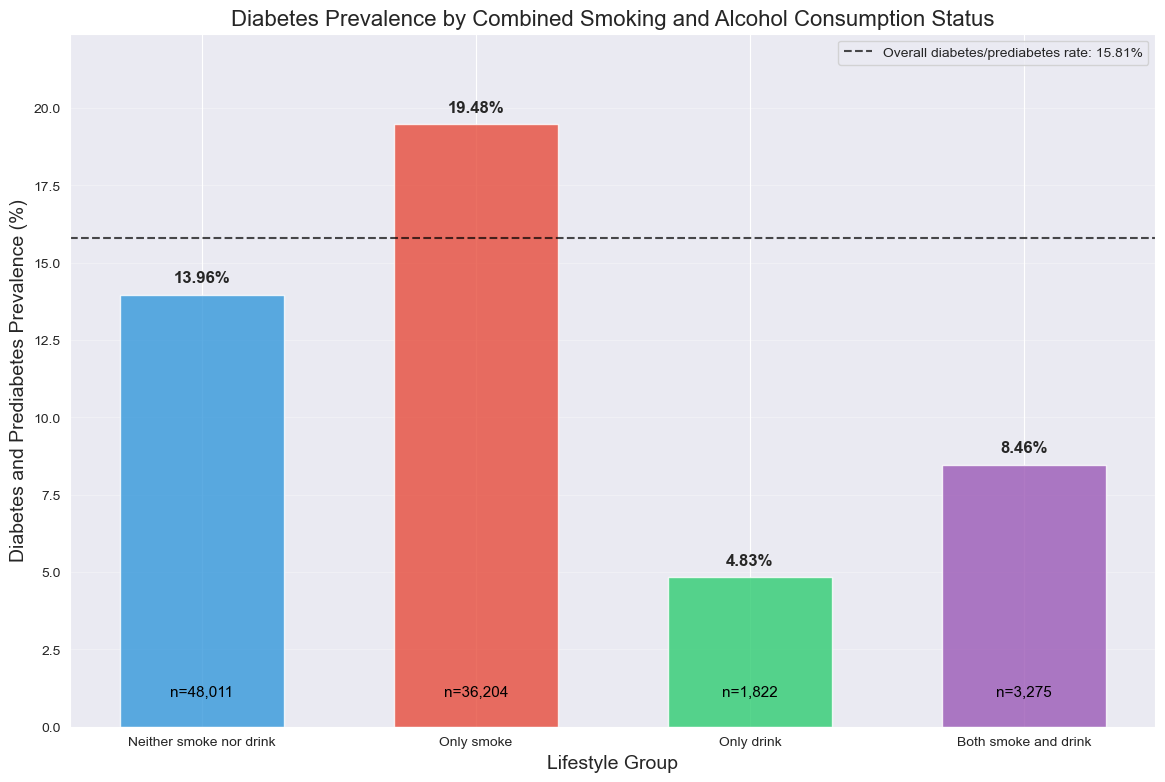


Contingency table (includes prediabetes):
has_diabetes             False  True 
lifestyle_group                      
Both smoke and drink      2998    277
Neither smoke nor drink  41309   6702
Only drink                1734     88
Only smoke               29152   7052

Distribution of lifestyle groups in the dataset:
  Neither smoke nor drink: 53.76%
  Only smoke: 40.54%
  Only drink: 2.04%
  Both smoke and drink: 3.67%


In [12]:
# Filter the data to include only valid smoking and alcohol status, and exclude "Prefer not to say" diabetes status
valid_data = df_cleaned[
    (~df_cleaned['Smoker'].isna()) &
    (~df_cleaned['Alcoholic'].isna()) &
    (df_cleaned['Diabetes'] != 'Prefer not to say')
    ].copy()

# Create a new binary diabetes status column that includes prediabetes as diabetes
valid_data['has_diabetes'] = valid_data['Diabetes'].isin(['Diabetes', 'Prediabetes'])

# Create a new column for the combined lifestyle status
valid_data['lifestyle_group'] = 'Unknown'
valid_data.loc[(valid_data['Smoker'] == False) & (valid_data['Alcoholic'] == False), 'lifestyle_group'] = 'Neither smoke nor drink'
valid_data.loc[(valid_data['Smoker'] == True) & (valid_data['Alcoholic'] == False), 'lifestyle_group'] = 'Only smoke'
valid_data.loc[(valid_data['Smoker'] == False) & (valid_data['Alcoholic'] == True), 'lifestyle_group'] = 'Only drink'
valid_data.loc[(valid_data['Smoker'] == True) & (valid_data['Alcoholic'] == True), 'lifestyle_group'] = 'Both smoke and drink'

# Define the specific order for the groups
group_order = ['Neither smoke nor drink', 'Only smoke', 'Only drink', 'Both smoke and drink']

# Calculate diabetes rates (including prediabetes) for each lifestyle group
diabetes_rates = []
sample_sizes = []

for group in group_order:
    group_data = valid_data[valid_data['lifestyle_group'] == group]
    total = len(group_data)
    diabetes_count = len(group_data[group_data['has_diabetes'] == True])
    rate = (diabetes_count / total) * 100 if total > 0 else 0

    diabetes_rates.append(rate)
    sample_sizes.append(total)

    # Print statistics for reference
    diabetes_only = len(group_data[group_data['Diabetes'] == 'Diabetes'])
    prediabetes_only = len(group_data[group_data['Diabetes'] == 'Prediabetes'])

    print(f"{group}:")
    print(f"  {diabetes_count:,} out of {total:,} people have diabetes or prediabetes ({rate:.2f}%)")
    print(f"    Diabetes: {diabetes_only:,} ({diabetes_only/total*100:.2f}%)")
    print(f"    Prediabetes: {prediabetes_only:,} ({prediabetes_only/total*100:.2f}%)")

# Create a figure
plt.figure(figsize=(14, 9))

# Define a color scheme
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']  # blue, red, green, purple

# Create the bar chart
bars = plt.bar(group_order, diabetes_rates, color=colors, alpha=0.8, width=0.6)

# Add data labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.3,
             f'{height:.2f}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add sample size labels below the category names
for i, count in enumerate(sample_sizes):
    plt.text(i, 1, f'n={count:,}', ha='center', color='black', fontsize=11)

# Add a horizontal line for the overall diabetes rate (including prediabetes)
overall_diabetes = valid_data[valid_data['has_diabetes'] == True]
overall_rate = len(overall_diabetes) / len(valid_data) * 100
plt.axhline(y=overall_rate, color='black', linestyle='--', alpha=0.7,
            label=f'Overall diabetes/prediabetes rate: {overall_rate:.2f}%')

# Customize the plot
plt.title('Diabetes Prevalence by Combined Smoking and Alcohol Consumption Status', fontsize=16)
plt.xlabel('Lifestyle Group', fontsize=14)
plt.ylabel('Diabetes and Prediabetes Prevalence (%)', fontsize=14)
plt.ylim(0, max(diabetes_rates) * 1.15)  # Add space for labels
plt.xticks(rotation=0)  # Keep labels horizontal
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)


# Save the figure and show it
plt.savefig('diabetes_combined_lifestyle.png', dpi=300, bbox_inches='tight')
plt.show()

# Create contingency table (now with has_diabetes which includes prediabetes)
contingency = pd.crosstab(valid_data['lifestyle_group'], valid_data['has_diabetes'])
print("\nContingency table (includes prediabetes):")
print(contingency)

# Calculate the percentage distribution of lifestyle groups
group_distribution = valid_data['lifestyle_group'].value_counts()
group_distribution_percent = (group_distribution / len(valid_data) * 100).sort_index()
print("\nDistribution of lifestyle groups in the dataset:")
for group, percent in zip(group_order, [group_distribution_percent.get(group, 0) for group in group_order]):
    print(f"  {group}: {percent:.2f}%")